# Integración Numérica
## Astrofísica Computacional

**Profesor:** Dr. Jose Ivan Campos Rozo  

En este notebook se resuelven:

1. Aproximación de una integral usando, **regla compuesta del trapecio**, **regla de simpson de 1/3 simple**,
2. Cálculo del área bajo la curva \(y=x^3\) usando **sumas de Riemann**.



In [50]:
#set up
import numpy as np
from scipy.integrate import quad
print("let's go")

let's go


# Ejercicio 1

La distancia vertical recorrida por un cohete entre \(t=8\) y \(t=30\) segundos está dada por

$
x=\int_{8}^{30}\left(2000\ln\left(\frac{140000}{140000-2100t}\right)-9.8t\right)dt
$

Definimos la función

$
f(t)=2000\ln\left(\frac{140000}{140000-2100t}\right)-9.8t
$
y aproximaremos la integral usando la **regla compuesta del trapecio**.

In [51]:
def f(t):
    return 2000*np.log(140000/(140000-2100*t)) - 9.8*t

## Regla compuesta del trapecio

La fórmula es

$
T_n=\frac{h}{2}\left[f(t_0)+2\sum_{i=1}^{n-1}f(t_i)+f(t_n)\right]
$

donde

$
h=\frac{b-a}{n}
$

In [52]:
def trapecio_compuesto(f,a,b,n):
    
    h=(b-a)/n
    t=np.linspace(a,b,n+1)
    
    T=h/2*(f(t[0]) + 2*np.sum(f(t[1:n])) + f(t[n]))
    
    return T

In [53]:
#Valor esperado de la INT

exacto,_ = quad(f,8,30)


### a)

In [54]:
a=8
b=30
n=1

aprox=trapecio_compuesto(f,a,b,n)

### b) y c)

In [55]:
Ea=abs(exacto-aprox)
Er=Ea/exacto*100
print("Error absoluto",Ea)
print(f"Error relativo {Er:.2f}%")

Error absoluto 807.0126547601249
Error relativo 7.30%


In [56]:
# tablas para diferentes n

import pandas as pd

n=np.arange(1,11)

aprox=[]
Ea=[]
Er=[]

for i in n:
    
    T=trapecio_compuesto(f,a,b,i)
    
    aprox.append(T)
    
    error_abs=abs(exacto-T)
    Ea.append(error_abs)
    
    error_rel=100*error_abs/abs(exacto)
    Er.append(error_rel)

tabla=pd.DataFrame({
    
    "n":n,
    "Aproximacion":aprox,
    "Error absoluto":Ea,
    "Error relativo %":Er
    
})

tabla


,n,Aproximacion,Error absoluto,Error relativo %
0,1,11868.348190,807.012655,7.295798
1,2,11266.374293,205.038758,1.853653
2,3,11152.759115,91.423580,0.826515
3,4,11112.820676,51.485141,0.465451
4,5,11094.303763,32.968228,0.298049
5,6,11084.236857,22.901322,0.207039
6,7,11078.163980,16.828444,0.152138
7,8,11074.221298,12.885763,0.116494
8,9,11071.517683,10.182148,0.092052
9,10,11069.583542,8.248007,0.074566


# EJERCICIO 2
Usar trapecio compuesto,simpson compuesto y simpson 3/8 para una funcion. y repetir numerales a,b,c. 

In [57]:
def simpson_compuesto(f,a,b,n):
    
    if n % 2 != 0:
        raise ValueError("n debe ser par para Simpson 1/3")
    
    h = (b-a)/n
    x = np.linspace(a,b,n+1)
    
    S = f(x[0]) + f(x[n])
    
    for i in range(1,n):
        
        if i % 2 == 0:
            S += 2*f(x[i])
        else:
            S += 4*f(x[i])
    
    S = S*h/3
    
    return S


In [58]:
def simpson_38(f,a,b,n):
    
    if n % 3 != 0:
        raise ValueError("n debe ser múltiplo de 3 para Simpson 3/8")
    
    h = (b-a)/n
    x = np.linspace(a,b,n+1)
    
    S = f(x[0]) + f(x[n])
    
    for i in range(1,n):
        
        if i % 3 == 0:
            S += 2*f(x[i])
        else:
            S += 3*f(x[i])
    
    S = 3*h*S/8
    
    return S

In [59]:
def y(x):
    return np.exp(-x**2)

In [63]:
import pandas as pd
import numpy as np

inf = 5
n=np.arange(1,15)

# valor teórico
I_exacto = np.sqrt(np.pi)

datos=[]

for i in n:
    
    # Trapecio
    TC = trapecio_compuesto(y,-inf,inf,i)
    Ea_TC = abs(I_exacto-TC)
    Er_TC = 100*Ea_TC/abs(I_exacto)
    
    # Simpson 1/3
    if i % 2 == 0:
        SC = simpson_compuesto(y,-inf,inf,i)
        Ea_SC = abs(I_exacto-SC)
        Er_SC = 100*Ea_SC/abs(I_exacto)
    else:
        SC = np.nan
        Ea_SC = np.nan
        Er_SC = np.nan
    
    # Simpson 3/8
    if i % 3 == 0:
        S38 = simpson_38(y,-inf,inf,i)
        Ea_S38 = abs(I_exacto-S38)
        Er_S38 = 100*Ea_S38/abs(I_exacto)
    else:
        S38 = np.nan
        Ea_S38 = np.nan
        Er_S38 = np.nan
    
    datos.append([
        i,
        TC,Ea_TC,Er_TC,
        SC,Ea_SC,Er_SC,
        S38,Ea_S38,Er_S38
    ])

tabla = pd.DataFrame(datos,columns=[
    
    "n",
    "Trapecio","Ea Trapecio","Er Trapecio %",
    "Simpson 1/3","Ea Simpson","Er Simpson %",
    "Simpson 3/8","Ea Simpson 3/8","Er Simpson 3/8 %"
])

tabla

,n,Trapecio,Ea Trapecio,Er Trapecio %,Simpson 1/3,Ea Simpson,Er Simpson %,Simpson 3/8,Ea Simpson 3/8,Er Simpson 3/8 %
0,1,1.388794e-10,1.772454e+00,1.000000e+02,NaN,NaN,NaN,NaN,NaN,NaN
1,2,5.000000e+00,3.227546e+00,1.820948e+02,6.666667,4.894213,276.126389,NaN,NaN,NaN
2,3,4.145102e-01,1.357944e+00,7.661377e+01,NaN,NaN,NaN,0.466324,1.306130,73.690490
3,4,2.509652e+00,7.371984e-01,4.159197e+01,1.679536,0.092917,5.242308,NaN,NaN,NaN
4,5,1.472011e+00,3.004424e-01,1.695065e+01,NaN,NaN,NaN,NaN,NaN,NaN
5,6,1.873972e+00,1.015177e-01,5.727524e+00,2.360459,0.588005,33.174621,1.483218,0.289236,16.318385
6,7,1.744315e+00,2.813912e-02,1.587580e+00,NaN,NaN,NaN,NaN,NaN,NaN
7,8,1.778857e+00,6.402705e-03,3.612340e-01,1.535258,0.237196,13.382344,NaN,NaN,NaN
8,9,1.771258e+00,1.195887e-03,6.747068e-02,NaN,NaN,NaN,1.940851,0.168398,9.500817
9,10,1.772637e+00,1.833539e-04,1.034464e-02,1.872846,0.100392,5.664009,NaN,NaN,NaN


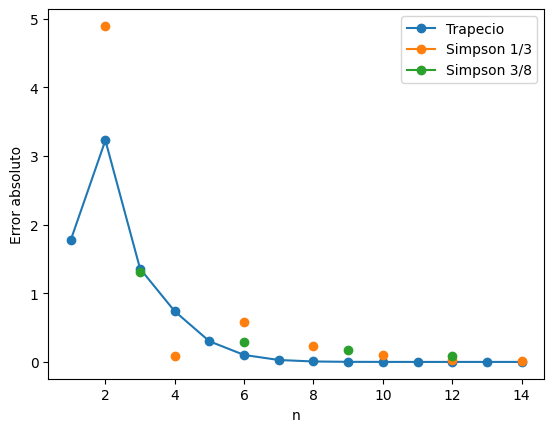

In [64]:
import matplotlib.pyplot as plt

plt.plot(tabla["n"],tabla["Ea Trapecio"],marker="o",label="Trapecio")

plt.plot(tabla["n"],tabla["Ea Simpson"],marker="o",label="Simpson 1/3")

plt.plot(tabla["n"],tabla["Ea Simpson 3/8"],marker="o",label="Simpson 3/8")
plt.xlabel("n")
plt.ylabel("Error absoluto")

plt.legend()

plt.show()

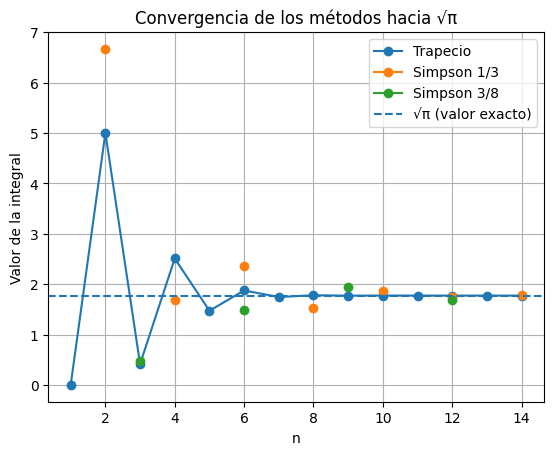

In [65]:
plt.figure()

plt.plot(tabla["n"],tabla["Trapecio"],marker="o",label="Trapecio")

plt.plot(tabla["n"],tabla["Simpson 1/3"],marker="o",label="Simpson 1/3")

plt.plot(tabla["n"],tabla["Simpson 3/8"],marker="o",label="Simpson 3/8")

plt.axhline(np.sqrt(np.pi),linestyle="--",label="√π (valor exacto)")

plt.xlabel("n")
plt.ylabel("Valor de la integral")

plt.title("Convergencia de los métodos hacia √π")

plt.legend()

plt.grid()

plt.show()

# Area bajo la curva Riemman

In [67]:
import numpy as np

def riemann_derecha(f,a,b,n):
    
    dx = (b-a)/n
    
    x = np.linspace(a+dx,b,n)
    
    S = np.sum(f(x))*dx
    
    return S

In [68]:
def z(x):
    return x**3



In [74]:
a = 0
b = 2
I_exacto = b**4/4
n = np.arange(1,21)

aprox = []

for i in n:
    
    aprox.append(riemann_derecha(z,a,b,i))


Ea=[]
Er=[]

for val in aprox:
    
    ea = abs(I_exacto-val)
    
    er = (ea/I_exacto)*100
    
    Ea.append(ea)
    
    Er.append(er)

tabla = pd.DataFrame({
    
    "n":n,
    "Riemann derecha":aprox,
    "Error absoluto":Ea,
    "Error relativo %":Er
    
})

tabla

,n,Riemann derecha,Error absoluto,Error relativo %
0,1,16.000000,12.000000,300.000000
1,2,9.000000,5.000000,125.000000
2,3,7.111111,3.111111,77.777778
3,4,6.250000,2.250000,56.250000
4,5,5.760000,1.760000,44.000000
5,6,5.444444,1.444444,36.111111
6,7,5.224490,1.224490,30.612245
7,8,5.062500,1.062500,26.562500
8,9,4.938272,0.938272,23.456790
9,10,4.840000,0.840000,21.000000


# EXTRA Animación
 

In [6]:
from manim import *
%load_ext manim

The manim module is not an IPython extension.


In [8]:
%%manim -ql RiemannSum

from manim import *

class RiemannSum(Scene):
    def construct(self):
        axes = Axes(
            x_range=[0, 3, 1],
            y_range=[0, 10, 2],
            x_length=6,
            y_length=4,
        )

        labels = axes.get_axis_labels(x_label="x", y_label="f(x)")
        graph = axes.plot(lambda x: x**2, color=BLUE)

        self.play(Create(axes), Write(labels))
        self.play(Create(graph))

        for n in [4, 8, 16,32,64,100]:
            rects = axes.get_riemann_rectangles(
                graph,
                x_range=[0, 3],
                dx=3/n,
                color=YELLOW,
                fill_opacity=0.6
            )

            self.play(FadeIn(rects))
            self.wait()
            self.play(FadeOut(rects))

        self.wait()

Manim Community v0.20.1

[03/06/26 22:16:57] INFO     Animation 0 : Partial movie file written in                   ]8;id=609417;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=906614;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/pipe/Computational_Astrophysics_2026-I_AFSR/Tareas/Eje                         
                             rcicios/media/videos/Ejercicios/480p15/partial_movie_files/Ri                         
                             emannSum/1584795214_1983804934_223132457.mp4'                                         

                    INFO     Animation 1 : Partial movie file written in                   ]8;id=981010;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=622565;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/pipe/Computational_Astrophysics_2026-I_AFSR/Tareas/Eje                         
                             rcicios/media/videos/Ejercicios/480p15/partial_movie_files/Ri                         
                             emannSum/4072820271_2283989956_3885464695.mp4'                                        

                    INFO     Animation 2 : Partial movie file written in                   ]8;id=423800;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=179026;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/pipe/Computational_Astrophysics_2026-I_AFSR/Tareas/Eje                         
                             rcicios/media/videos/Ejercicios/480p15/partial_movie_files/Ri                         
                             emannSum/4072820271_1388424651_3591557731.mp4'                                        

                    INFO     Animation 3 : Partial movie file written in                   ]8;id=510880;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=747386;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/pipe/Computational_Astrophysics_2026-I_AFSR/Tareas/Eje                         
                             rcicios/media/videos/Ejercicios/480p15/partial_movie_files/Ri                         
                             emannSum/4072820271_2834709167_1277765497.mp4'                                        

...

[03/06/26 22:17:01] INFO     Animation 19 : Partial movie file written in                  ]8;id=927068;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=813337;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/pipe/Computational_Astrophysics_2026-I_AFSR/Tareas/Eje                         
                             rcicios/media/videos/Ejercicios/480p15/partial_movie_files/Ri                         
                             emannSum/4072820271_3170620156_4101261626.mp4'                                        

                    INFO     Animation 20 : Partial movie file written in                  ]8;id=393790;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=232839;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/home/pipe/Computational_Astrophysics_2026-I_AFSR/Tareas/Eje                         
                             rcicios/media/videos/Ejercicios/480p15/partial_movie_files/Ri                         
                             emannSum/4072820271_2834709167_1579039851.mp4'                                        

                    INFO     Combining to Movie file.                                      ]8;id=864333;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=510659;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#753\753]8;;\

                    INFO                                                                   ]8;id=919433;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=25356;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#904\904]8;;\
                             File ready at                                                                         
                             '/home/pipe/Computational_Astrophysics_2026-I_AFSR/Tareas/Eje                         
                             rcicios/media/videos/Ejercicios/480p15/RiemannSum.mp4'                                
                                                                                                                   

                    INFO     Rendered RiemannSum                                                       ]8;id=405448;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene.py\scene.py]8;;\:]8;id=814358;file:///home/pipe/Computational_Astrophysics_2026-I_AFSR/entorno_ASTRO/lib/python3.12/site-packages/manim/scene/scene.py#278\278]8;;\
                             Played 21 animations                                                                  